# SALES ANALYSIS

In [8]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os

### Merging 12 month of sales data into a single file

In [9]:
path = "C:/Users/owner's/Desktop/Pandas-Data-Science-Tasks-master/SalesAnalysis/Sales_Data"

In [10]:
files = [file for file in os.listdir(path) if file.endswith('.csv')]

all_months_data = pd.DataFrame()

for file in files:
    df = pd.read_csv(path + "/" + file)
    all_months_data = pd.concat([all_months_data, df])

all_months_data.to_csv("all_data.csv", index=False)

In [11]:
all_data = pd.read_csv("all_data.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


#### Removing null values

In [12]:
all_data.shape

(186850, 6)

In [13]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


In [14]:
all_data.dropna(inplace=True)

In [19]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4.0
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4.0
3,176560,Google Phone,1,600,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4.0


#### Add month column

In [20]:
all_data = all_data[all_data["Order Date"] != "Or"]
all_data["Order Date"] = pd.to_datetime(all_data['Order Date'],errors="coerce")
all_data['Month'] =all_data['Order Date'].dt.month

In [21]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4.0
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4.0
3,176560,Google Phone,1,600,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4.0


#### Add column sales

In [22]:
all_data["Quantity Ordered"]=pd.to_numeric(all_data["Quantity Ordered"],errors="coerce")
all_data["Price Each"]=pd.to_numeric(all_data["Price Each"],errors="coerce")


In [23]:
all_data["Sales"]=all_data["Quantity Ordered"]*all_data["Price Each"]
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4.0,23.90
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4.0,99.99
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,600.00
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,11.99
5,176561,Wired Headphones,1.0,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4.0,11.99


### Best Month for Sales and its earnings

Text(0, 0.5, 'Sales in USD')

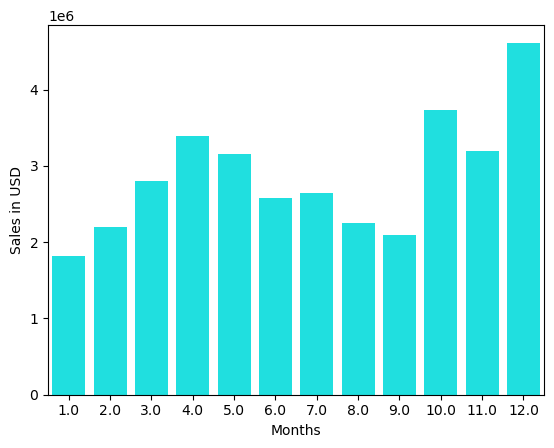

In [24]:
a=all_data.groupby("Month")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=a.index,y=a.values,color="cyan")
plt.xlabel("Months")
plt.ylabel("Sales in USD")

In [ ]:
### Insight:
Sales peak in December, indicating a strong seasonal trend driven by holiday shopping and increased consumer spending.
    Businesses should increase inventory and marketing efforts during this period to maximize revenue.

#### Add colum City

In [25]:
def get_city(address):
    try:
        return address.split(",")[1].strip()
    except:
        return ""

def get_state(address):
    try:
        return address.split(",")[2].split(" ")[1].strip()
    except:
        return ""

all_data["City"]=all_data["Purchase Address"].apply(lambda x : get_city(x)+""+get_state(x))
all_data["City"]

0                DallasTX
2                BostonMA
3           Los AngelesCA
4           Los AngelesCA
5           Los AngelesCA
               ...       
186845      Los AngelesCA
186846    San FranciscoCA
186847    San FranciscoCA
186848    San FranciscoCA
186849    San FranciscoCA
Name: City, Length: 186305, dtype: object

### City that have highest no. of sales

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, ''),
  Text(1, 0, 'AtlantaGA'),
  Text(2, 0, 'AustinTX'),
  Text(3, 0, 'BostonMA'),
  Text(4, 0, 'DallasTX'),
  Text(5, 0, 'Los AngelesCA'),
  Text(6, 0, 'New York CityNY'),
  Text(7, 0, 'PortlandME'),
  Text(8, 0, 'PortlandOR'),
  Text(9, 0, 'San FranciscoCA'),
  Text(10, 0, 'SeattleWA')])

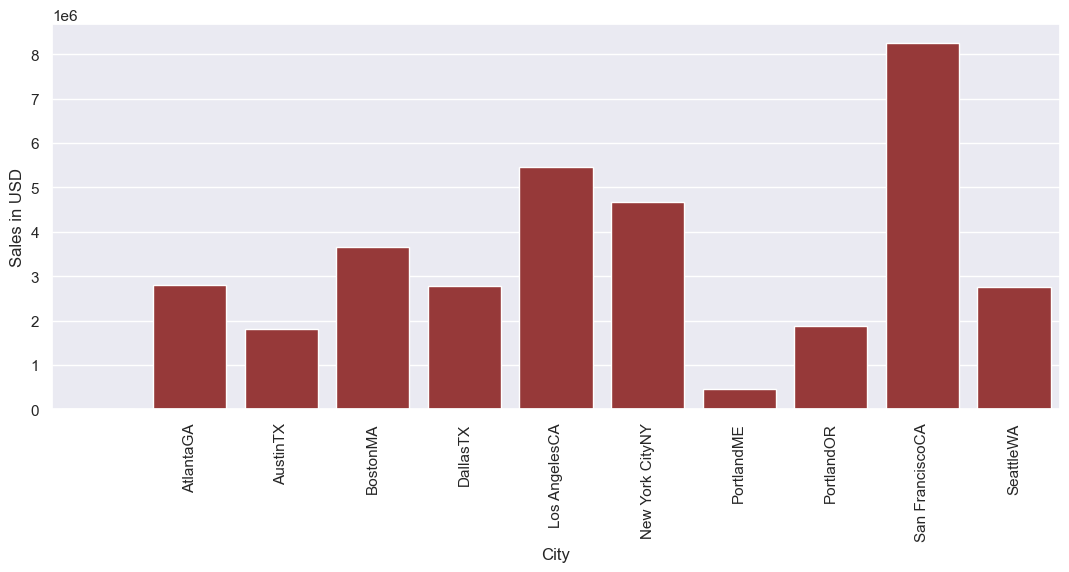

In [26]:
a=all_data.groupby("City")["Sales"].sum()
sns.set(rc={"figure.figsize":(13,5)})
sns.barplot(x=a.index,y=a.values,color="brown")
plt.xlabel("City")
plt.ylabel("Sales in USD")
plt.xticks(rotation=90)

In [ ]:
### Insight:
Certain cities show significantly higher sales, likely due to higher population density and purchasing power. 
    Businesses should focus on targeted marketing campaigns and logistics optimization in these high-performing regions.

### Best time to display advertisments to maximize customer purchase

#### Add columns Hour ,Minute

In [27]:
all_data["Order Date"]=pd.to_datetime(all_data["Order Date"],errors="coerce")
all_data["Hour"]=all_data["Order Date"].dt.hour
all_data["Minute"]=all_data["Order Date"].dt.minute
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Minute
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4.0,23.90,DallasTX,8.0,46.0
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4.0,99.99,BostonMA,22.0,30.0
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,600.00,Los AngelesCA,14.0,38.0
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4.0,11.99,Los AngelesCA,14.0,38.0
5,176561,Wired Headphones,1.0,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4.0,11.99,Los AngelesCA,9.0,27.0


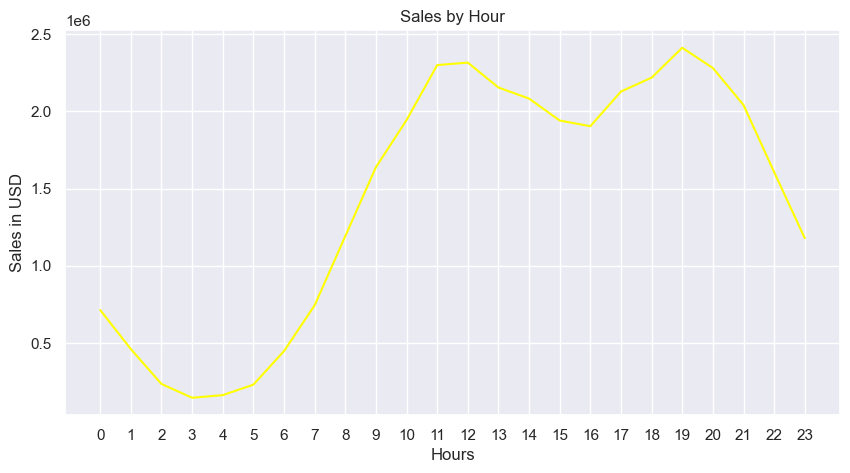

In [28]:
a = all_data.groupby("Hour")["Sales"].sum().sort_index()
sns.set(rc={"figure.figsize":(10,5)})
plt.plot(a.index, a.values, color="yellow")
plt.xticks(a.index)
plt.grid(True)
plt.xlabel("Hours")
plt.ylabel("Sales in USD")
plt.title("Sales by Hour")
plt.show()


In [ ]:
### Insight:
Sales are highest during evening hours (around 11 PM), suggesting that customers prefer shopping after work. 
    Running targeted advertisements and promotions during this time can significantly boost sales.

### Products sold often together

In [29]:
df = all_data[all_data["Order ID"].duplicated(keep=False)]
df["Grouped"]= df.groupby("Order ID")["Product"].transform(lambda x: ",".join(x))
df =df[["Order ID","Grouped"]].drop_duplicates()
df.head()

C:\Users\owner's\AppData\Local\Temp\ipykernel_9448\2429453045.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Grouped"]= df.groupby("Order ID")["Product"].transform(lambda x: ",".join(x))


,Order ID,Grouped
3,176560,"Google Phone,Wired Headphones"
18,176574,"Google Phone,USB-C Charging Cable"
30,176585,"Bose SoundSport Headphones,Bose SoundSport Hea..."
32,176586,"AAA Batteries (4-pack),Google Phone"
119,176672,"Lightning Charging Cable,USB-C Charging Cable"


In [ ]:
### Insight:
Certain products are frequently purchased together, suggesting an opportunity for bundling and cross-selling.
    Offering combo deals on these products can increase average order value.

In [30]:
from itertools import combinations
from collections import Counter

In [31]:
count=Counter()
for row in df["Grouped"]:
    row_list = row.split(",")
    count.update(Counter(combinations(row_list,3)))
for key , values in count.most_common(10):
    print(key,values)

('Product', 'Product', 'Product') 7393585
('Google Phone', 'USB-C Charging Cable', 'Wired Headphones') 87
('iPhone', 'Lightning Charging Cable', 'Wired Headphones') 62
('iPhone', 'Lightning Charging Cable', 'Apple Airpods Headphones') 47
('Google Phone', 'USB-C Charging Cable', 'Bose SoundSport Headphones') 35
('Vareebadd Phone', 'USB-C Charging Cable', 'Wired Headphones') 33
('iPhone', 'Apple Airpods Headphones', 'Wired Headphones') 27
('Google Phone', 'Bose SoundSport Headphones', 'Wired Headphones') 24
('Vareebadd Phone', 'USB-C Charging Cable', 'Bose SoundSport Headphones') 16
('USB-C Charging Cable', 'Bose SoundSport Headphones', 'Wired Headphones') 5


### Product sold the most

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, '20in Monitor'),
  Text(1, 0, '27in 4K Gaming Monitor'),
  Text(2, 0, '27in FHD Monitor'),
  Text(3, 0, '34in Ultrawide Monitor'),
  Text(4, 0, 'AA Batteries (4-pack)'),
  Text(5, 0, 'AAA Batteries (4-pack)'),
  Text(6, 0, 'Apple Airpods Headphones'),
  Text(7, 0, 'Bose SoundSport Headphones'),
  Text(8, 0, 'Flatscreen TV'),
  Text(9, 0, 'Google Phone'),
  Text(10, 0, 'LG Dryer'),
  Text(11, 0, 'LG Washing Machine'),
  Text(12, 0, 'Lightning Charging Cable'),
  Text(13, 0, 'Macbook Pro Laptop'),
  Text(14, 0, 'Product'),
  Text(15, 0, 'ThinkPad Laptop'),
  Text(16, 0, 'USB-C Charging Cable'),
  Text(17, 0, 'Vareebadd Phone'),
  Text(18, 0, 'Wired Headphones'),
  Text(19, 0, 'iPhone')])

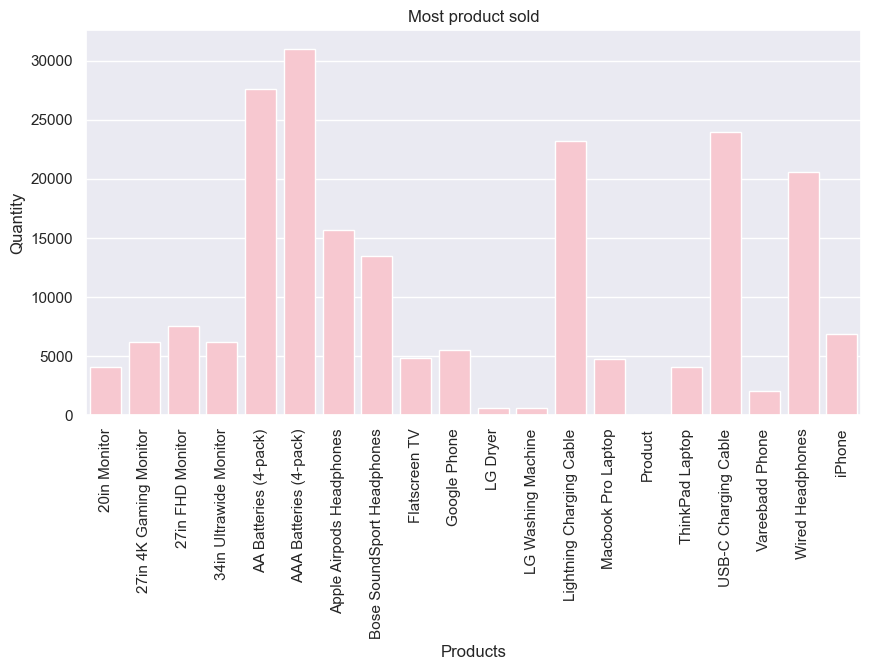

In [32]:
a=all_data.groupby("Product")["Quantity Ordered"].sum()
sns.barplot(x=a.index,y=a.values,color="pink")
plt.title("Most product sold")
plt.xlabel("Products")
plt.ylabel("Quantity")
plt.xticks(rotation = 90)

In [ ]:
### Insight:
Products with lower prices tend to have higher purchase quantities, while expensive products sell less frequently.
    A balanced pricing strategy can help optimize both sales volume and revenue.